In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns

In [ ]:
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"

df = pd.read_csv(url)

df.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [ ]:
print("Number of rows:", df.shape[0])

print("Number of columns:", df.shape[1])

print("\nColumn names:")

print(df.columns.tolist())

Number of rows: 400
Number of columns: 4

Column names:
['admit', 'gre', 'gpa', 'rank']


In [ ]:
df.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [ ]:
df.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [ ]:
feature_cols = ["gre", "gpa", "rank"]

x = df[feature_cols]

y = df["admit"]

In [ ]:
print(x)

print(y)

     gre   gpa  rank
0    380  3.61     3
1    660  3.67     3
2    800  4.00     1
3    640  3.19     4
4    520  2.93     4
..   ...   ...   ...
395  620  4.00     2
396  560  3.04     3
397  460  2.63     2
398  700  3.65     2
399  600  3.89     3

[400 rows x 3 columns]
0      0
1      1
2      1
3      1
4      0
      ..
395    0
396    0
397    0
398    0
399    0
Name: admit, Length: 400, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=0
)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(300, 3)
(300,)
(100, 3)
(100,)


In [ ]:
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

In [ ]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print(y_test.values)

[0 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 1 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 1]


In [ ]:
conf_mat = metrics.confusion_matrix(
    y_test,
    y_pred
)

print(conf_mat)

[[61  4]
 [27  8]]


In [ ]:
accuracy = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.69


In [ ]:
print("Accuracy in percentage:", accuracy * 100, "%")

Accuracy in percentage: 69.0 %


<Axes: xlabel='Predicted', ylabel='Actual'>

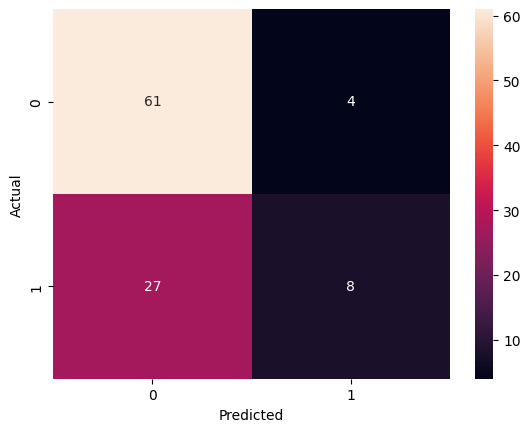

In [ ]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

sns.heatmap(
    conf_mat,
    annot=True
)